In [1]:
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import pandas as pd
from gensim import corpora
from gensim.models import LdaModel
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from transformers import pipeline
from wordcloud import WordCloud

nltk_dir = os.path.abspath("nltk_data")
os.makedirs("nltk_data", exist_ok=True)
nltk.data.path.append(nltk_dir)
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab")

/data/BillWatcher-2.0/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /home/cheeleong/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/cheeleong/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/cheeleong/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/cheeleong/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
md_files = []
search_dir = "scraper_data/en/live/2024"

for root, dirs, files in os.walk(search_dir):
    for file in files:
        if file.endswith(".md"):
            full_path = os.path.join(root, file)
            md_files.append(full_path)

In [3]:
# Create a list to store DataFrames
dataframes = []

# Read each file and create a DataFrame
for file_path in md_files:
    with open(file_path, "r", encoding="utf-8") as file:
        content = file.read()
        df = pd.DataFrame({"filename": [file_path], "content": [content]})
        dataframes.append(df)

# Combine all DataFrames
all_content_df = pd.concat(dataframes, ignore_index=True)
print(f"Loaded {len(all_content_df)} files into DataFrame")
display(all_content_df)

Loaded 10 files into DataFrame


,filename,content
0,scraper_data/en/live/2024/2024_3/bill.md,---\nYear: 2024\nBill: D.R. 3/2024 - Unclaimed...
1,scraper_data/en/live/2024/2024_6/bill.md,---\nYear: 2024\nBill: D.R. 6/2024 - Police (A...
2,scraper_data/en/live/2024/2024_2/bill.md,---\nYear: 2024\nBill: D.R. 2/2024 - Licensed ...
3,scraper_data/en/live/2024/2024_1/bill.md,---\nYear: 2024\nBill: D.R. 1/2024 - Money Ser...
4,scraper_data/en/live/2024/2024_0/bill.md,---\nYear: 2024\nBill: D.R.10/2024 - Labuan Bu...
5,scraper_data/en/live/2024/2024_5/bill.md,---\nYear: 2024\nBill: D.R. 5/2024 - Supply (R...
6,scraper_data/en/live/2024/2024_8/bill.md,---\nYear: 2024\nBill: D.R. 8/2024 - Cyber Sec...
7,scraper_data/en/live/2024/2024_7/bill.md,---\nYear: 2024\nBill: D.R. 7/2024 - Limited L...
8,scraper_data/en/live/2024/2024_9/bill.md,---\nYear: 2024\nBill: D.R. 9/2024 - Income Ta...
9,scraper_data/en/live/2024/2024_4/bill.md,---\nYear: 2024\nBill: D.R. 4/2024 - Supplemen...


In [4]:
def preprocess_text(text):
    # Remove special characters and numbers
    text = re.sub(r"\W+", " ", text)
    text = re.sub(r"\d+", "", text)

    # Tokenize and lowercase
    tokens = word_tokenize(text.lower())

    # Remove stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

In [5]:
# Apply preprocessing to the content column
all_content_df["processed_text"] = all_content_df["content"].apply(preprocess_text)
print("Preprocessing complete. Sample of processed text:")
print(all_content_df["processed_text"].head())

Preprocessing complete. Sample of processed text:
0    [year, bill, r, unclaimed, money, amendment, b...
1    [year, bill, r, police, amendment, bill, title...
2    [year, bill, r, licensed, land, surveyor, amen...
3    [year, bill, r, money, service, business, amen...
4    [year, bill, r, labuan, business, activity, ta...
Name: processed_text, dtype: object


In [6]:
def get_word_frequencies(tokens):
    return Counter(tokens)

In [7]:
# Concatenate all processed text tokens into one list
all_tokens = []
for tokens in all_content_df["processed_text"]:
    all_tokens.extend(tokens)

# Get word frequencies using the existing function
word_freq = get_word_frequencies(all_tokens)

# Convert to DataFrame for better visualization
word_freq_df = pd.DataFrame.from_dict(word_freq, orient="index", columns=["frequency"])
word_freq_df = word_freq_df.sort_values("frequency", ascending=False)

# Display top 20 most frequent words
print("Top 20 most frequent words:")
print(word_freq_df.head(20))

Top 20 most frequent words:
               frequency
_                    683
section              412
act                  312
subsection           292
shall                266
employee             265
word                 242
ordinance            222
b                    205
employer             202
amendment            169
director             168
may                  167
seek                 133
person               129
substituting         125
arbitration          115
amended              114
service              108
accommodation        105


In [8]:
def perform_topic_modeling(tokens, num_topics=5):
    dictionary = corpora.Dictionary([tokens])
    corpus = [dictionary.doc2bow(tokens)]
    lda_model = LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=15)
    return lda_model.print_topics()

In [9]:
# Apply topic modeling to each document's processed text
num_topics = 5
topics_list = []
for text in all_content_df["processed_text"]:
    topics = perform_topic_modeling(text, num_topics)
    topics_list.append(topics)

# Display the topics for each document
for i, topics in enumerate(topics_list):
    print(f"\nDocument {i + 1} Topics:")
    for topic in topics:
        print(topic)


Document 1 Topics:
(0, '0.004*"_" + 0.004*"act" + 0.004*"word" + 0.004*"subsection" + 0.004*"water" + 0.004*"section" + 0.004*"amendment" + 0.004*"supply" + 0.004*"service" + 0.004*"principal"')
(1, '0.004*"_" + 0.004*"word" + 0.004*"act" + 0.004*"subsection" + 0.004*"section" + 0.004*"amendment" + 0.004*"water" + 0.004*"service" + 0.004*"principal" + 0.004*"paragraph"')
(2, '0.004*"word" + 0.004*"_" + 0.004*"subsection" + 0.004*"amendment" + 0.004*"act" + 0.004*"section" + 0.004*"water" + 0.004*"amended" + 0.004*"principal" + 0.004*"inserting"')
(3, '0.004*"_" + 0.004*"subsection" + 0.004*"act" + 0.004*"amendment" + 0.004*"water" + 0.004*"word" + 0.004*"section" + 0.004*"principal" + 0.004*"substituting" + 0.004*"amend"')
(4, '0.050*"_" + 0.037*"word" + 0.036*"act" + 0.033*"subsection" + 0.025*"section" + 0.021*"amendment" + 0.018*"water" + 0.014*"service" + 0.013*"amended" + 0.013*"principal"')

Document 2 Topics:
(0, '0.010*"act" + 0.010*"dr" + 0.010*"bill" + 0.010*"section" + 0.01

In [10]:
summarizer = pipeline("summarization", max_length=130, min_length=30, device=0)

def summarize_text(text):
    try:
        # Truncate text if it's too long (transformers typically has a limit)
        text = text[:1024]  # Limiting to first 1024 characters
        # Return as pandas Series to maintain consistency
        result = summarizer(text)[0]['summary_text']
        return pd.Series([result])
    except Exception as e:
        print(f"Error summarizing text: {e}")
        return pd.Series(["Summary generation failed"])

# Apply summarization to all documents
all_content_df['summary'] = all_content_df['content'].apply(lambda x: summarize_text(x)[0])

# Display results
print("\nSummarization Results:")
display(all_content_df[['filename', 'summary']])

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.



Summarization Results:


,filename,summary
0,scraper_data/en/live/2024/2024_3/bill.md,Bill: D.R. 3/2024 - Unclaimed Moneys (Amendme...
1,scraper_data/en/live/2024/2024_6/bill.md,Bill: D.R. 6/2024 - Police (Amendment) Bill 2...
2,scraper_data/en/live/2024/2024_2/bill.md,Bill: D.R. 2/2024 - Licensed Land Surveyors (...
3,scraper_data/en/live/2024/2024_1/bill.md,Bill: D.R. 1/2024 - Money Services Business (...
4,scraper_data/en/live/2024/2024_0/bill.md,Bill: D.R.10/2024 - Labuan Business Activity ...
5,scraper_data/en/live/2024/2024_5/bill.md,Bill: D.R. 5/2024 - Supply (Reallocation of A...
6,scraper_data/en/live/2024/2024_8/bill.md,Bill: D.R. 8/2024 - Cyber Security Bill 2024....
7,scraper_data/en/live/2024/2024_7/bill.md,Bill: D.R. 7/2024 - Limited Liability Partner...
8,scraper_data/en/live/2024/2024_9/bill.md,Bill: D.R. 9/2024 - Income Tax (Amendment) Bi...
9,scraper_data/en/live/2024/2024_4/bill.md,Bill: D.R. 4/2024 - Supplementary Supply (202...


In [11]:
sentiment_analyzer = pipeline("sentiment-analysis", max_length=512, truncation=True, device=0)

def analyze_sentiment(text):
    try:
        # Truncate text if it's too long
        text = text[:5000]  # Limit text length
        result = sentiment_analyzer(text)
        if isinstance(result, list) and len(result) > 0:
            return pd.Series([result[0]['label'], result[0]['score']])
        return pd.Series(['UNKNOWN', 0.0])
    except Exception as e:
        print(f"Error analyzing text: {e}")
        return pd.Series(['ERROR', 0.0])

# Apply sentiment analysis to all documents
sentiment_results = all_content_df['content'].apply(analyze_sentiment)
all_content_df[['sentiment', 'sentiment_score']] = sentiment_results

# Display results
print("\nSentiment Analysis Results:")
print(all_content_df[['filename', 'sentiment', 'sentiment_score']])

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.



Sentiment Analysis Results:
                                   filename sentiment  sentiment_score
0  scraper_data/en/live/2024/2024_3/bill.md  NEGATIVE         0.992238
1  scraper_data/en/live/2024/2024_6/bill.md  NEGATIVE         0.996288
2  scraper_data/en/live/2024/2024_2/bill.md  NEGATIVE         0.996503
3  scraper_data/en/live/2024/2024_1/bill.md  NEGATIVE         0.995680
4  scraper_data/en/live/2024/2024_0/bill.md  NEGATIVE         0.996171
5  scraper_data/en/live/2024/2024_5/bill.md  NEGATIVE         0.996710
6  scraper_data/en/live/2024/2024_8/bill.md  NEGATIVE         0.995578
7  scraper_data/en/live/2024/2024_7/bill.md  NEGATIVE         0.995447
8  scraper_data/en/live/2024/2024_9/bill.md  NEGATIVE         0.997459
9  scraper_data/en/live/2024/2024_4/bill.md  NEGATIVE         0.996662


In [12]:
# Remove single character tokens and special characters
cleaned_tokens = [token for token in all_tokens if len(token) > 1 and token.isalnum()]

# Update the word frequencies with cleaned tokens
word_freq = Counter(cleaned_tokens)

# Convert to DataFrame and sort
word_freq_df = pd.DataFrame.from_dict(word_freq, orient="index", columns=["frequency"])
word_freq_df = word_freq_df.sort_values("frequency", ascending=False)

# Display top 20 most frequent words
print("Top 20 most frequent words after cleanup:")
print(word_freq_df.head(20))

Top 20 most frequent words after cleanup:
               frequency
section              412
act                  312
subsection           292
shall                266
employee             265
word                 242
ordinance            222
employer             202
amendment            169
director             168
may                  167
seek                 133
person               129
substituting         125
arbitration          115
amended              114
service              108
accommodation        105
party                 97
government            94


In [13]:
# Define tokens to filter out (common technical and structural words)
filter_words = {'act', 'section', 'subsection', 'shall', 'bill', 'year', 'pdf', 'url', 'http', 'www', 
               'parlimen', 'gov', 'file', 'dr', 'bi', 'reading', 'passed', 'presented', 'yb', 
               'download', 'filename', 'menteri', 'datuk', 'puan'}

# Filter out non-topic tokens and keep only meaningful ones
topic_tokens = [token for token in cleaned_tokens if token not in filter_words]

# Update word frequencies with filtered tokens
topic_word_freq = Counter(topic_tokens)

# Convert to DataFrame and sort
topic_freq_df = pd.DataFrame.from_dict(topic_word_freq, orient="index", columns=["frequency"])
topic_freq_df = topic_freq_df.sort_values("frequency", ascending=False)

# Display top 20 most frequent topic-related words
print("Top 20 most frequent topic-related words:")
print(topic_freq_df.head(20))

Top 20 most frequent topic-related words:
               frequency
employee             265
word                 242
ordinance            222
employer             202
amendment            169
director             168
may                  167
seek                 133
person               129
substituting         125
arbitration          115
amended              114
service              108
accommodation        105
party                 97
government            94
work                  94
made                  81
part                  80
provide               79


In [23]:
# Create a regex pattern for word-only tokens (letters only)
word_pattern = re.compile(r'^[a-zA-Z]+$')

# Function to filter word-only tokens
def filter_word_tokens(tokens):
    return [token for token in tokens if word_pattern.match(token) and len(token) > 1]

# Apply the filter to processed_text column
all_content_df['processed_text'] = all_content_df['processed_text'].apply(filter_word_tokens)

# Update all_tokens with word-only tokens
all_tokens = []
for tokens in all_content_df['processed_text']:
    all_tokens.extend(tokens)

print(f"Number of tokens after filtering: {len(all_tokens)}")
print("\nSample of cleaned tokens:")
print(all_tokens[:20])

print("Top 20 most frequent topic-related words:")
print(topic_freq_df.head(20))

Number of tokens after filtering: 15932

Sample of cleaned tokens:
['year', 'bill', 'unclaimed', 'money', 'amendment', 'bill', 'title', 'unclaimed', 'money', 'amendment', 'bill', 'download', 'url', 'http', 'www', 'parlimen', 'gov', 'file', 'billindex', 'pdf']
Top 20 most frequent topic-related words:
               frequency
employee             265
word                 242
ordinance            222
employer             202
amendment            169
director             168
may                  167
seek                 133
person               129
substituting         125
arbitration          115
amended              114
service              108
accommodation        105
party                 97
government            94
work                  94
made                  81
part                  80
provide               79


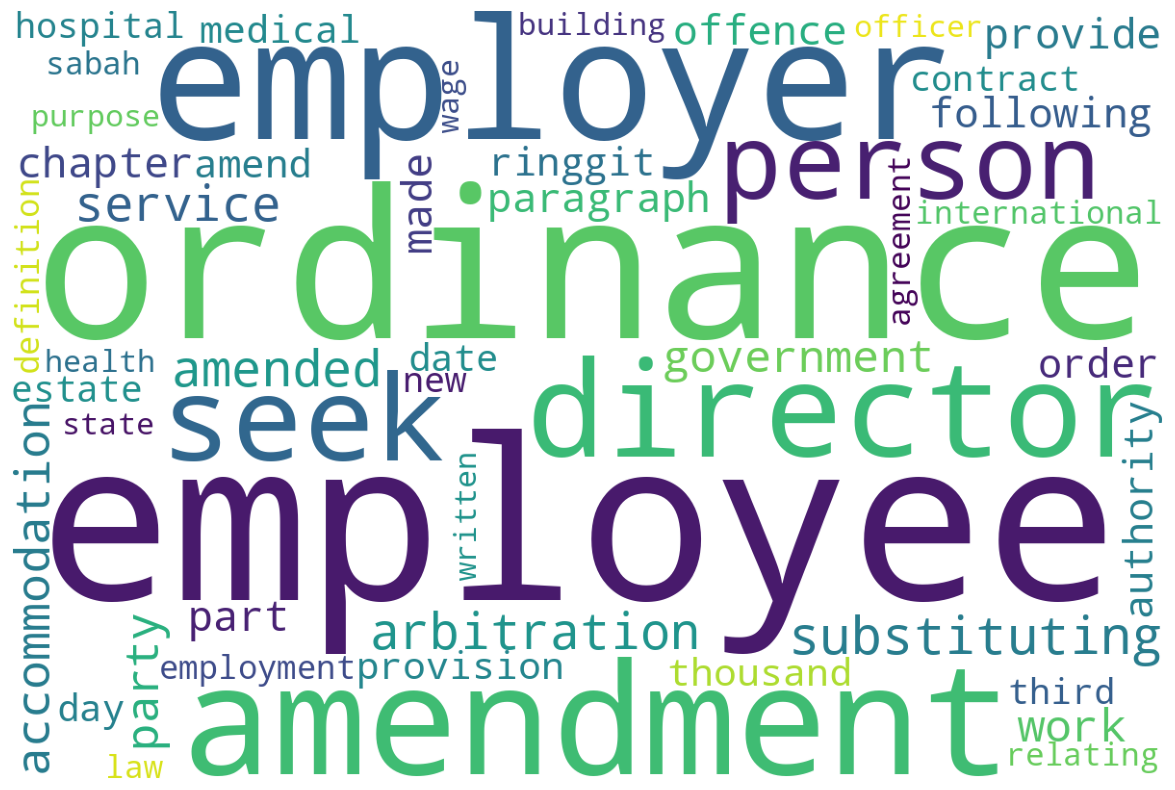

In [22]:
# Filter out common legislative terms, conjunctions, and prepositions
unwanted_words = {
    'act', 'section', 'subsection', 'shall', 'bill', 'year', 'word', 'may', 'pdf', 'url',
    'and', 'or', 'but', 'nor', 'for', 'yet', 'so',  # conjunctions
    'in', 'on', 'at', 'to', 'with', 'by', 'from', 'of', 'under', 'between',  # prepositions
    'inserting', 
}

# Create word frequency dictionary excluding unwanted words
word_freq_dict = {word: freq for word, freq in word_freq.items() 
                 if word not in unwanted_words and len(word) > 2}

# Create and generate word cloud
wordcloud = WordCloud(
    width=1200, 
    height=800,
    background_color='white',
    max_words=50,
    colormap='viridis'
).generate_from_frequencies(word_freq_dict)

# Display the word cloud
plt.figure(figsize=(15,10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()
